In [2]:
import pandas as pd

df = pd.read_csv(r"C:/Databases/heart.csv")
print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [6]:
#1. Train a Decision Tree Classifier and Visualize the Tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X.columns,
                           class_names=["No Disease", "Disease"],
                           filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("heart_tree", format='png', cleanup=True)
graph.view("heart_tree")


'heart_tree.pdf'

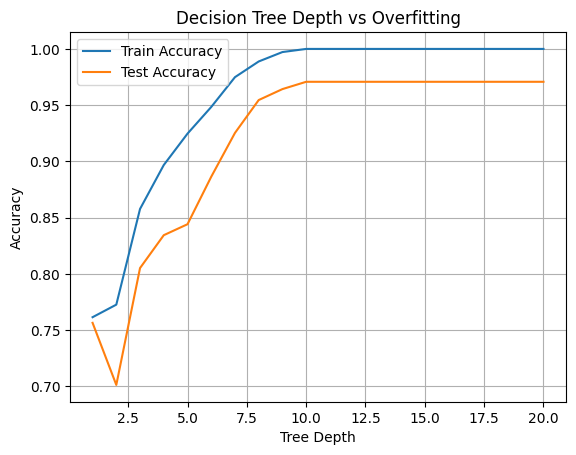

In [ ]:
#2. Analyze Overfitting and Control Tree Depth
import matplotlib.pyplot as plt

train_acc, test_acc = [], []
depths = range(1, 21)

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Overfitting")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
#3. Train a Random Forest and Compare Accuracy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

dt_accuracy = clf.score(X_test, y_test)
rf_accuracy = rf.score(X_test, y_test)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")


Decision Tree Accuracy: 0.97
Random Forest Accuracy: 0.98


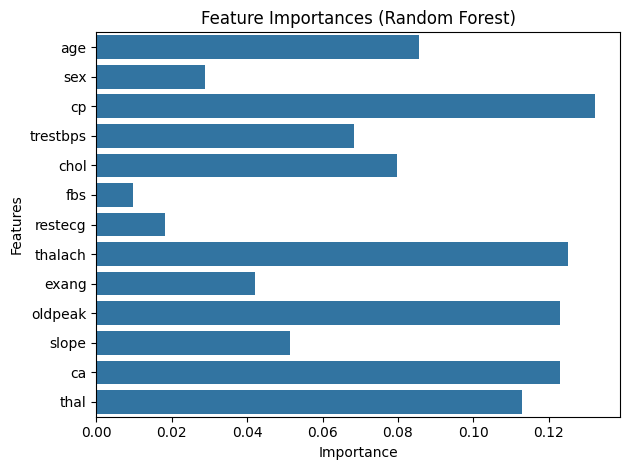

In [6]:
#4.Interpret Feature Importances
import seaborn as sns

importances = rf.feature_importances_
features = X.columns

# Plot
sns.barplot(x=importances, y=features)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [7]:
#5.Evaluate Using Cross-Validation
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(clf, X, y, cv=5)
rf_cv = cross_val_score(rf, X, y, cv=5)

print(f"Decision Tree CV Accuracy: {dt_cv.mean():.2f}")
print(f"Random Forest CV Accuracy: {rf_cv.mean():.2f}")


Decision Tree CV Accuracy: 1.00
Random Forest CV Accuracy: 1.00
